# Автоматизация обработки данных о поездках Яндекс Такси
- Автор: Стогниева Дарья Александровна
- Дата: 28.09.2026

## Описание проекта

Мы будем работать с данными сервиса Яндекс Такси. Каждый день компания обрабатывает миллионы поездок, оплаченных разными способами. Чтобы финансовая и продуктовая команды регулярно получали актуальные данные о выручке и поведении пассажиров, коллеги решили настроить автоматическую обработку этих данных.

Наша задача - построить витрину данных, которая будет агрегировать информацию о поездках по каждому способу оплаты. Для этого нужно написать PySpark-скрипт, который рассчитает ключевые показатели: количество поездок, среднюю стоимость поездки, средние чаевые и суммарную выручку по каждому типу оплаты.

Чтобы процесс был полностью автоматическим и не зависел от ручных запусков, необходимо создать DAG в Airflow. Этот DAG должен ежедневно:

* проверять наличие новых файлов с данными;

* запускать Spark-задачу;

* формировать обновлённую итоговую таблицу.

Эта таблица станет основой для финансовых отчётов и аналитических дашбордов.

## Описание данных

Таблица `taxi_data` содержит данные об активности пользователей и состоит из следующих полей:

* `taxi_id` — идентификатор водителя;

* `trip_start_timestamp` — время начала поездки;

* `trip_end_timestamp` — время окончания поездки;

* `trip_seconds` — длительность поездки в секундах;

* `trip_miles` — дистанция поездки;

* `fare` — стоимость поездки;

* `tips` — размер чаевых;

* `trip_total` — общая стоимость поездки: стоимость поездки + чаевые + комиссия;

* `payment_type` — способ оплаты.

## Что нужно сделать

В проекте нам предстоит автоматизировать подготовку витрины данных по поездкам Яндекс Такси:

1. Сначала необходимо написать Spark-скрипт, который будет обрабатывать данные о поездках и агрегировать показатели по способам оплаты `payment_type`. Понадобится рассчитать несколько показателей:

* количество поездок, которое показывает общий спрос и загрузку сервиса;
* среднюю стоимость `fare`, которое отражает уровень среднего чека поездки;
* средние чаевые `tips` — индикатор удовлетворённости клиентов и мотивации водителей;
* суммарную выручку `trip_total` — ключевой показатель дохода компании.

Все результаты должны собираться в одну итоговую таблицу `taxi_payment_summary`. После этого таблицу нужно записать в ClickHouse с помощью JDBC-драйвера.

2. Далее нам понадобится настроить DAG в Airflow. DAG должен запускаться ежедневно. Перед запуском он проверяет наличие файла с данными за нужную дату в S3-хранилище и только после появления файла запускает Spark-задачу.

## Шаг 1. Настройка Spark-агрегации

Данные хранятся в формате Parquet, поэтому для чтения используем метод `spark.read.parquet()`. Это быстрее и надёжнее, чем CSV.

Сгруппируем данные по полю `payment_type` и рассчитаем четыре показателя:

* количество поездок — `count(*)`;
* среднюю стоимость — `avg(...)`;
* средние чаевые — `avg(...)`;
* суммарную выручку — `sum(...)`.

Так получится витрина для анализа информации по каждому способу оплаты. После этого настроим запись полученной таблицы в ClickHouse.

In [ ]:
# Код для создания таблицы в ClickHouse
CREATE TABLE taxi_payment_summary
(
    payment_type String,
    total_rides Int64,
    avg_fare Float64,
    avg_tips Float64,
    total_revenue Float64
)
ENGINE = MergeTree()
ORDER BY payment_type;

In [ ]:
#filename=my_spark_job.py

# импортируем библиотеки
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Создаем Spark-сессию
spark = (
SparkSession.builder.appName("myAggregateTest")
.config("fs.s3a.endpoint", "storage.yandexcloud.net")
.config("spark.dynamicAllocation.enabled", "false")
.config("spark.executor.instances", "1")
.config("spark.executor.cores", "1")
.config("spark.executor.memory", "1g")
.config("spark.driver.memory", "1g")
.getOrCreate()
)

# Указываем порт и параметры кластера ClickHouse
jdbcPort = 8443
jdbcHostname = "rc1a-3jouval14nne7aun.mdb.yandexcloud.net"
username = "da_20260818_5dbb5ce275"
jdbcDatabase = "playground_" + username
jdbcUrl = f"jdbc:clickhouse://{jdbcHostname}:{jdbcPort}/{jdbcDatabase}?ssl=true"

# Считываем исходные данные
parquet_path = "s3a://da-plus-dags/project_04/taxi_data.parquet"
df_from_parquet = spark.read.parquet(parquet_path)

# Группируем данные по payment_type и считаем метрики
taxi_payment_summary = (
    df_from_parquet
    .groupBy("payment_type")
    .agg(
        F.count("*").alias("total_rides"),          # количество поездок
        F.avg("fare").alias("avg_fare"),            # средняя стоимость
        F.avg("tips").alias("avg_tips"),            # средние чаевые
        F.sum("trip_total").alias("total_revenue")  # суммарная выручка
    )
)

# Записываем данные в таблицу ClickHouse
taxi_payment_summary.write.format("jdbc") \
    .option("url", jdbcUrl) \
    .option("user", username) \
    .option("password", "c60819148bd74e65bc237d1c58b69927") \
    .option("dbtable", "taxi_payment_summary") \
    .mode("append") \
    .save()

## Шаг 2. НастройкаDAG

В DAG будем использовать `S3KeySensor`, чтобы дождаться появления файла в S3. После этого запустим `DataprocCreatePysparkJobOperator`, передав путь к нашему скрипту.

In [ ]:
#filename=my_spark_job.py

from datetime import datetime
from airflow import DAG
from airflow.sensors.s3_key_sensor import S3KeySensor
from airflow.providers.yandex.operators.dataproc import DataprocCreatePysparkJobOperator

DAG_ID = "yandex_taxi_analysis"

with DAG(
    DAG_ID,
    schedule_interval='@daily',
    start_date=datetime(2025, 1, 1),
    tags=["taxi_data_aggregate"],
    catchup=False
) as dag:
    # 1) Ждём появления входного файла в S3
    wait_for_input = S3KeySensor(
    task_id='data_s3_sensor',
    bucket_name="da-plus-dags",
    bucket_key='project_04/taxi_data.parquet',
    aws_conn_id="s3",
    poke_interval=60 * 5,
    timeout=60 * 60,
    mode="poke",
    wildcard_match=False
    )

    # 2) Запускаем PySpark-задание на кластере Dataproc (оператор Яндекс Облака)
    run_pyspark = DataprocCreatePysparkJobOperator(
        task_id="create_pyspark_job",
        name="yandex_taxi_aggregate",
        cluster_id="c9q4134h5vi546h1e148",
        main_python_file_uri=f"s3a://da-plus-dags/da_20260818_5dbb5ce275/jobs/my_spark_job.py",
)

    # 3)  Зависимости 
    wait_for_input >> run_pyspark

## Шаг 3. Запуск DAG с помощью Airflow UI

Теперь можно переходить к запуску. Проверим, что DAG выполнился, а результат соответствует ожиданиям.

DAG выполнился успешно:
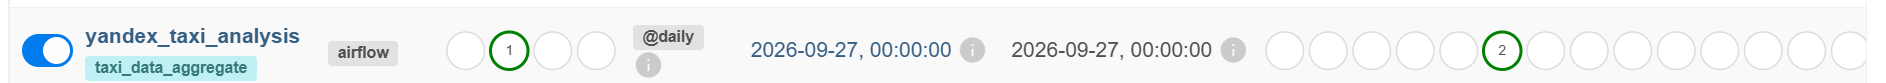

Резльтат таблицы в ClickHouse:
    
|payment_type|total_rides|avg_fare          |avg_tips            |total_revenue     |
|------------|-----------|------------------|--------------------|------------------|
|Cash        |    1410155|11.194248598877067|0.003325194540318936|16971150.869999863|
|Credit Card |    1108843|15.869293343229563|   3.477157157788922|23160130.960003342|
|Dispute     |       1842|13.327953311617806|                 0.0|          27052.29|
|No Charge   |      12843|13.535953437670331|  0.1256941524565911|184374.59000000003|
|Prcard      |        968|11.172262396694215| 0.25764462809917354|11513.149999999998|
|Unknown     |       5180| 11.79162804171493| 0.35713595983005136| 67725.07000000005|
|Way2ride    |          3|               3.5|  0.7933333333333333|14.379999999999999|
|Pcard       |        878| 9.833428246013668| 0.18314350797266515|           9175.55|